In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries loaded")

Libraries loaded


In [2]:
base_path = r"D:\Dataset\Anmol-MP-EV"

processed_path = os.path.join(
    base_path,
    "processed_data"
)

station_features = pd.read_csv(
    os.path.join(
        processed_path,
        "kmeans_cluster_results.csv"
    )
)

station_features.head()

,Station,Metric_Type,Peak,Valley,Peak_Valley_Difference,Average,Load_Factor,Cluster
0,A1,Power(kW),1688.9,0.0,1688.9,269.163615,0.159372,1
1,A2,Power(kW),3020.3,0.0,3020.3,674.418259,0.223295,2
2,A3,Power(kW),3418.8,0.0,3418.8,576.626919,0.168664,2
3,A4,Power(kW),8896.8,0.0,8896.8,1239.017558,0.139266,0
4,A5,Power(kW),61.6,0.0,61.6,8.028525,0.130333,1


In [3]:
X = station_features[
    [
        "Peak",
        "Peak_Valley_Difference",
        "Load_Factor"
    ]
]

y = station_features["Average"]

print(X.head())
print(y.head())

     Peak  Peak_Valley_Difference  Load_Factor
0  1688.9                  1688.9     0.159372
1  3020.3                  3020.3     0.223295
2  3418.8                  3418.8     0.168664
3  8896.8                  8896.8     0.139266
4    61.6                    61.6     0.130333
0     269.163615
1     674.418259
2     576.626919
3    1239.017558
4       8.028525
Name: Average, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data split completed")

Data split completed


In [5]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

print("Model trained")

Model trained


In [6]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 273.98140884004806
RMSE: 281.0633049848558
R2 Score: -22.174615389017294


In [7]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Peak,0.485389
1,Peak_Valley_Difference,0.472879
2,Load_Factor,0.041732


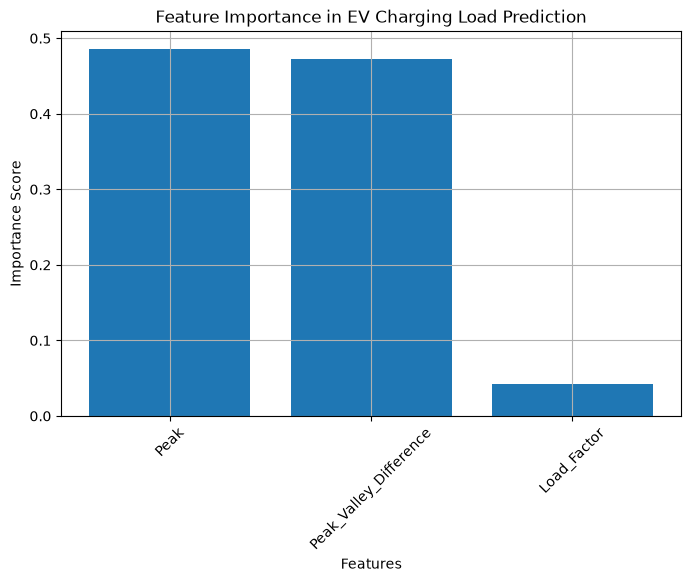

In [8]:
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance in EV Charging Load Prediction")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [9]:
feature_importance.to_csv(
    os.path.join(processed_path, "feature_importance.csv"),
    index=False
)

print("Feature importance saved")

Feature importance saved


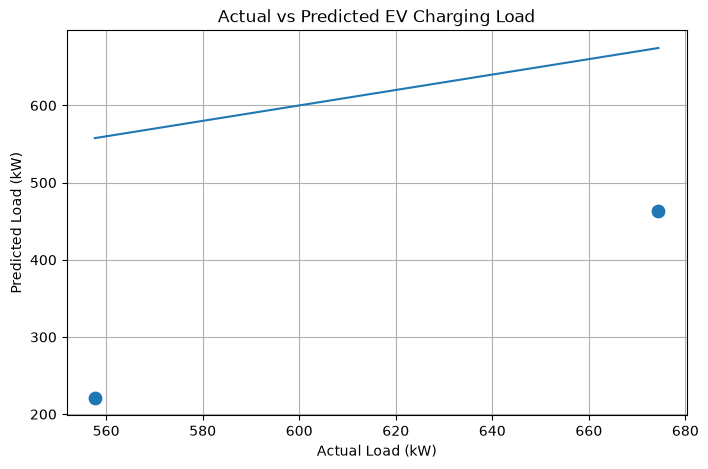

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred,
    s=80
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.title("Actual vs Predicted EV Charging Load")
plt.xlabel("Actual Load (kW)")
plt.ylabel("Predicted Load (kW)")

plt.grid(True)

plt.show()

In [11]:
prediction_results = pd.DataFrame({
    "Actual_Load": y_test,
    "Predicted_Load": y_pred
})

prediction_results.to_csv(
    os.path.join(processed_path, "prediction_results.csv"),
    index=False
)

prediction_results

,Actual_Load,Predicted_Load
8,557.649174,220.971920
1,674.418259,463.132695


In [12]:
model_summary = {
    "Model": "Random Forest Regression",
    "Objective": "Predict EV charging load",
    "Features Used": list(X.columns),
    "MAE": mae,
    "RMSE": rmse,
    "R2_Score": r2
}

pd.DataFrame([model_summary])

,Model,Objective,Features Used,MAE,RMSE,R2_Score
0,Random Forest Regression,Predict EV charging load,"[Peak, Peak_Valley_Difference, Load_Factor]",273.981409,281.063305,-22.174615
